# MAKE A COPY DULU YA GUYS 📌

Sebelum mulai, buka notebook ini di **Google Colab** lalu lakukan:

**File → Save a copy in Drive**

Kenapa harus di-*copy*?
- supaya versi asli tetap aman,
- supaya kamu bisa edit bagian `TODO`,
- supaya hasil eksperimenmu tersimpan di Drive sendiri.

# Challenge Notebook — CIFAR-10: MLP vs CNN with TensorFlow

Notebook ini adalah **challenge lanjutan** untuk peserta workshop **Intro to Deep Learning & Computer Vision**.

Di challenge ini kamu **tidak perlu mulai dari nol**.  
Tugasmu adalah **mengisi bagian-bagian yang masih kosong (`TODO`)**, lalu menjalankan eksperimen sampai selesai.

---

## Target challenge

Pada akhir notebook ini, kamu diharapkan bisa:

1. memuat dan memahami dataset **CIFAR-10**,
2. melakukan **preprocessing** data gambar,
3. melatih **model MLP** sebagai baseline,
4. melatih **model CNN** untuk data citra,
5. membandingkan performa **MLP vs CNN**,
6. melakukan **inferensi** menggunakan model terbaik,
7. membuat kesimpulan sederhana dari hasil eksperimen.

---

## Output yang diharapkan

| Bagian | Yang harus ada |
|---|---|
| Eksplorasi data | Visualisasi sampel gambar CIFAR-10 |
| Preprocessing | Data ternormalisasi dan siap untuk MLP & CNN |
| Model 1 | MLP terlatih |
| Model 2 | CNN terlatih |
| Evaluasi | Accuracy / loss / confusion matrix / sample predictions |
| Perbandingan | Kesimpulan model mana yang lebih baik dan kenapa |
| Inferensi | Prediksi pada beberapa gambar test |

> **Catatan:** Fokus challenge ini bukan bikin semuanya dari nol, tapi memahami **alur kerja computer vision end-to-end** dan melihat perbedaan representasi **MLP vs CNN**.

## Aturan pengerjaan

- Kerjakan notebook **dari atas ke bawah**.
- Isi bagian yang diberi tanda **`TODO`**.
- Jangan hapus helper function yang sudah disediakan.
- Kalau ada error, baca pesan error-nya baik-baik — biasanya ada petunjuk bagian mana yang belum diisi.
- Setelah selesai, tulis kesimpulanmu di bagian refleksi akhir.

---

## Strategi pengerjaan yang disarankan

1. Pastikan runtime Colab sudah memakai **GPU** bila tersedia.
2. Jalankan bagian **setup** dan **helper** terlebih dahulu.
3. Isi TODO untuk **load data** dan **preprocessing**.
4. Latih **MLP** dulu sebagai baseline.
5. Latih **CNN**, lalu bandingkan hasilnya.
6. Jalankan bagian **visualisasi** dan **inferensi**.
7. Kerjakan **bonus** kalau masih ada waktu.

In [ ]:

# ============================================
# 1. Setup Environment & Import Libraries
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("TensorFlow version:", tf.__version__)
print("GPU detected:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU detected: []


## Konfigurasi eksperimen

Untuk mempercepat runtime saat challenge, kamu bisa mulai dari **subset data** terlebih dahulu.  
Kalau semua sudah berjalan baik, kamu bisa coba ulang dengan **full dataset**.

### Saran
- `USE_SUBSET = True` saat debugging awal
- `USE_SUBSET = False` saat final run

In [ ]:

# ============================================
# 2. Konfigurasi
# ============================================

USE_SUBSET = True

TRAIN_SAMPLES = 20000   # dipakai kalau USE_SUBSET=True
TEST_SAMPLES  = 4000    # dipakai kalau USE_SUBSET=True

BATCH_SIZE = 64
EPOCHS_MLP = 10
EPOCHS_CNN = 12
VAL_RATIO = 0.1

IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
NUM_CLASSES = 10

## Helper functions

Bagian ini sudah disediakan agar kamu tidak perlu menulis ulang fungsi visualisasi dari nol.
Jalankan saja cell di bawah ini.

In [ ]:

# ============================================
# 3. Helper Functions
# ============================================

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def show_class_distribution(labels, title="Distribusi Label"):
    labels = np.array(labels).reshape(-1)
    counts = pd.Series(labels).value_counts().sort_index()
    df_counts = pd.DataFrame({
        "class_id": counts.index,
        "class_name": [CLASS_NAMES[i] for i in counts.index],
        "count": counts.values
    })
    display(df_counts)

    plt.figure(figsize=(10, 4))
    plt.bar(df_counts["class_name"], df_counts["count"])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

def plot_history(history, title_prefix="Model"):
    hist = history.history
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_conf_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def show_prediction_grid(images, true_labels, pred_probs, class_names, n=12):
    true_labels = np.array(true_labels).reshape(-1)
    pred_labels = np.argmax(pred_probs, axis=1)

    n = min(n, len(images))
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 3.5 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.xticks([])
        plt.yticks([])

        true_name = class_names[true_labels[i]]
        pred_name = class_names[pred_labels[i]]
        conf = pred_probs[i][pred_labels[i]]

        color = "green" if true_name == pred_name else "red"
        plt.title(
            f"Pred: {pred_name}\nTrue: {true_name}\nConf: {conf:.2f}",
            color=color,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

# Part A — Load & Explore CIFAR-10

## 1. Load dataset

Isi bagian `TODO` di bawah ini untuk memuat dataset **CIFAR-10**.

### Petunjuk
- Gunakan `keras.datasets.cifar10.load_data()`
- Kalau `USE_SUBSET=True`, ambil sebagian data saja
- Simpan hasilnya ke variabel:
  - `x_train`
  - `y_train`
  - `x_test`
  - `y_test`

### Yang perlu kamu cek
- shape data train
- shape label train
- shape data test
- shape label test

In [ ]:

# ============================================
# 4. TODO — Load CIFAR-10
# ============================================

# TODO:
# 1) Load CIFAR-10
# 2) Terapkan subset bila USE_SUBSET=True
# 3) Simpan ke x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = None, None, None, None

# ===== TULIS KODE DI SINI =====

(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()

if USE_SUBSET:
    x_train = x_train_full[:TRAIN_SAMPLES]
    y_train = y_train_full[:TRAIN_SAMPLES]
    x_test  = x_test_full[:TEST_SAMPLES]
    y_test  = y_test_full[:TEST_SAMPLES]
else:
    x_train = x_train_full
    y_train = y_train_full
    x_test  = x_test_full
    y_test  = y_test_full

# ===== BATAS TODO =====

if x_train is None or y_train is None or x_test is None or y_test is None:
    raise ValueError("Isi bagian TODO terlebih dahulu.")

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (20000, 32, 32, 3)
y_train shape: (20000, 1)
x_test shape : (4000, 32, 32, 3)
y_test shape : (4000, 1)


In [ ]:

# Quick check
assert x_train.ndim == 4 and x_train.shape[1:] == (32, 32, 3), "Shape x_train harus (N, 32, 32, 3)"
assert y_train.ndim == 2 and y_train.shape[1] == 1, "Shape y_train harus (N, 1)"
assert len(np.unique(y_train)) == 10, "Label train harus berisi 10 kelas"
print("✅ Dataset berhasil dimuat dengan format yang benar.")

✅ Dataset berhasil dimuat dengan format yang benar.


## 2. Eksplorasi awal dataset

Sekarang tampilkan:
- beberapa gambar sampel dari CIFAR-10,
- nama kelas tiap gambar,
- distribusi label pada data train.

### Tantangan kecil
Coba amati:
- kelas mana yang paling sering muncul?
- apakah distribusinya seimbang?

/tmp/ipykernel_774/3320548800.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[i].set_title(CLASS_NAMES[int(y_train[i])], fontsize=10)


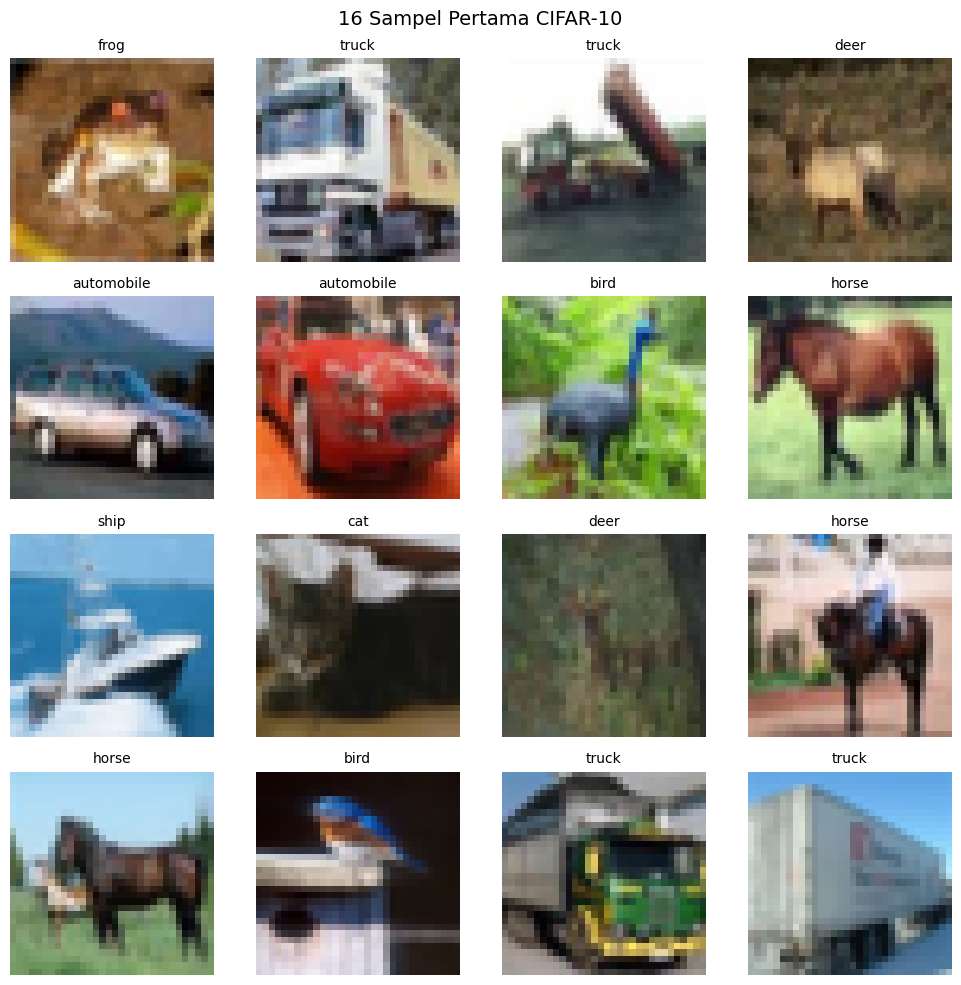

In [ ]:

# ============================================
# 5. TODO — Visualisasi sample images
# ============================================

# TODO:
# Tampilkan 16 gambar pertama dari x_train
# Tampilkan nama kelasnya menggunakan CLASS_NAMES
# Gunakan figsize yang cukup besar agar rapi

# ===== TULIS KODE DI SINI =====

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(x_train[i])
    axes[i].set_title(CLASS_NAMES[int(y_train[i])], fontsize=10)
    axes[i].axis("off")

plt.suptitle("16 Sampel Pertama CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

# ===== BATAS TODO =====


,class_id,class_name,count
0,0,airplane,1989
1,1,automobile,1981
2,2,bird,2042
3,3,cat,2011
4,4,deer,2009
5,5,dog,1925
6,6,frog,2038
7,7,horse,2027
8,8,ship,2012
9,9,truck,1966


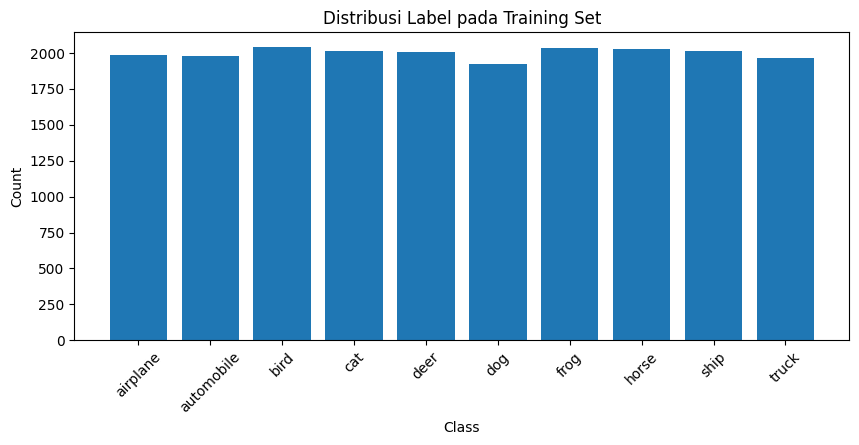

In [ ]:

# Distribusi label
show_class_distribution(y_train, title="Distribusi Label pada Training Set")

# Part B — Preprocessing

Sebelum masuk ke training, data perlu disiapkan.

## Kenapa preprocessing penting?

| Langkah | Tujuan |
|---|---|
| Normalisasi pixel | Membuat training lebih stabil |
| Flatten untuk MLP | Karena MLP menerima input vektor 1D |
| Menjaga bentuk 32×32×3 untuk CNN | Karena CNN butuh struktur spasial gambar |
| Validation split | Supaya kita bisa memantau generalisasi model |

---

## Tugasmu
Isi bagian TODO di bawah untuk:
1. menormalisasi pixel ke rentang **0–1**,
2. membuat versi data untuk **MLP**,
3. membuat versi data untuk **CNN**,
4. membagi training menjadi **train** dan **validation**.

In [ ]:

# ============================================
# 6. TODO — Preprocessing
# ============================================

# Target variabel yang harus tersedia setelah TODO:
# x_train_norm, x_test_norm
# x_train_mlp, x_val_mlp, x_test_mlp
# x_train_cnn, x_val_cnn, x_test_cnn
# y_train_split, y_val_split, y_test_ready

x_train_norm, x_test_norm = None, None
x_train_mlp, x_val_mlp, x_test_mlp = None, None, None
x_train_cnn, x_val_cnn, x_test_cnn = None, None, None
y_train_split, y_val_split, y_test_ready = None, None, None

# ===== TULIS KODE DI SINI =====

# Normalisasi pixel ke rentang 0–1
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32")  / 255.0

# Hitung jumlah data validasi dari VAL_RATIO
n_val = int(len(x_train_norm) * VAL_RATIO)
n_train = len(x_train_norm) - n_val

# Label
y_train_split = y_train[:n_train]
y_val_split   = y_train[n_train:]
y_test_ready  = y_test

# Versi MLP: flatten (N, 32*32*3)
x_train_mlp = x_train_norm[:n_train].reshape(n_train, IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS)
x_val_mlp   = x_train_norm[n_train:].reshape(n_val,   IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS)
x_test_mlp  = x_test_norm.reshape(len(x_test_norm),   IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS)

# Versi CNN: pertahankan bentuk (N, 32, 32, 3)
x_train_cnn = x_train_norm[:n_train]
x_val_cnn   = x_train_norm[n_train:]
x_test_cnn  = x_test_norm

# ===== BATAS TODO =====

required_vars = [
    x_train_norm, x_test_norm,
    x_train_mlp, x_val_mlp, x_test_mlp,
    x_train_cnn, x_val_cnn, x_test_cnn,
    y_train_split, y_val_split, y_test_ready
]

if any(v is None for v in required_vars):
    raise ValueError("Masih ada variabel preprocessing yang belum diisi.")

print("x_train_mlp:", x_train_mlp.shape)
print("x_val_mlp  :", x_val_mlp.shape)
print("x_test_mlp :", x_test_mlp.shape)
print("x_train_cnn:", x_train_cnn.shape)
print("x_val_cnn  :", x_val_cnn.shape)
print("x_test_cnn :", x_test_cnn.shape)
print("y_train    :", y_train_split.shape)
print("y_val      :", y_val_split.shape)
print("y_test     :", y_test_ready.shape)


x_train_mlp: (18000, 3072)
x_val_mlp  : (2000, 3072)
x_test_mlp : (4000, 3072)
x_train_cnn: (18000, 32, 32, 3)
x_val_cnn  : (2000, 32, 32, 3)
x_test_cnn : (4000, 32, 32, 3)
y_train    : (18000, 1)
y_val      : (2000, 1)
y_test     : (4000, 1)


In [ ]:

# Quick checks
assert np.max(x_train_norm) <= 1.0 and np.min(x_train_norm) >= 0.0, "Normalisasi belum benar."
assert x_train_mlp.ndim == 2 and x_train_mlp.shape[1] == 32*32*3, "MLP harus pakai input flatten."
assert x_train_cnn.ndim == 4 and x_train_cnn.shape[1:] == (32, 32, 3), "CNN harus pakai input 4D."
print("✅ Preprocessing siap digunakan.")

✅ Preprocessing siap digunakan.


# Part C — Baseline Model: MLP

MLP akan menjadi **baseline**.  
Model ini tetap bisa dipakai untuk klasifikasi gambar, tetapi ia **tidak mempertahankan struktur spasial** gambar secara eksplisit.

## Tugasmu
Isi TODO untuk:
- membuat arsitektur MLP,
- melakukan compile,
- menjalankan training.

### Saran arsitektur awal
Kamu boleh mulai dari:
- Dense 512
- Dropout
- Dense 256
- Output 10 kelas

> Kamu boleh memodifikasi jumlah neuron, aktivasi, atau dropout jika ingin bereksperimen.

In [ ]:

# ============================================
# 7. TODO — Build MLP
# ============================================

mlp_model = None

# ===== TULIS KODE DI SINI =====
# Mengikuti style dari notebook referensi:
# - tf.keras.Sequential
# - Dense + ReLU untuk hidden layer
# - Dropout untuk regularisasi
# - output: 10 neuron + softmax

mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH * IMG_CHANNELS,)),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

# ===== BATAS TODO =====

if mlp_model is None:
    raise ValueError("MLP model belum dibuat.")

mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# ============================================
# 8. TODO — Compile & Train MLP
# ============================================

history_mlp = None

# ===== TULIS KODE DI SINI =====

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mlp = mlp_model.fit(
    x_train_mlp, y_train_split,
    validation_data=(x_val_mlp, y_val_split),
    epochs=EPOCHS_MLP,
    batch_size=BATCH_SIZE,
    verbose=2
)

# ===== BATAS TODO =====

if history_mlp is None:
    raise ValueError("Training MLP belum dijalankan.")


Epoch 1/10
282/282 - 13s - 45ms/step - accuracy: 0.2131 - loss: 2.1404 - val_accuracy: 0.3225 - val_loss: 1.9121
Epoch 2/10
282/282 - 8s - 30ms/step - accuracy: 0.2580 - loss: 1.9935 - val_accuracy: 0.3290 - val_loss: 1.8697
Epoch 3/10
282/282 - 8s - 27ms/step - accuracy: 0.2834 - loss: 1.9489 - val_accuracy: 0.3085 - val_loss: 1.8749
Epoch 4/10
282/282 - 8s - 30ms/step - accuracy: 0.2943 - loss: 1.9156 - val_accuracy: 0.3565 - val_loss: 1.8288
Epoch 5/10
282/282 - 7s - 26ms/step - accuracy: 0.3109 - loss: 1.8913 - val_accuracy: 0.3535 - val_loss: 1.7985
Epoch 6/10
282/282 - 8s - 29ms/step - accuracy: 0.3191 - loss: 1.8697 - val_accuracy: 0.3675 - val_loss: 1.7815
Epoch 7/10
282/282 - 8s - 29ms/step - accuracy: 0.3226 - loss: 1.8536 - val_accuracy: 0.3700 - val_loss: 1.7810
Epoch 8/10
282/282 - 7s - 26ms/step - accuracy: 0.3290 - loss: 1.8325 - val_accuracy: 0.3775 - val_loss: 1.7548
Epoch 9/10
282/282 - 8s - 29ms/step - accuracy: 0.3359 - loss: 1.8170 - val_accuracy: 0.3675 - val_loss

MLP Test Accuracy: 0.3820
MLP Test Loss    : 1.7542


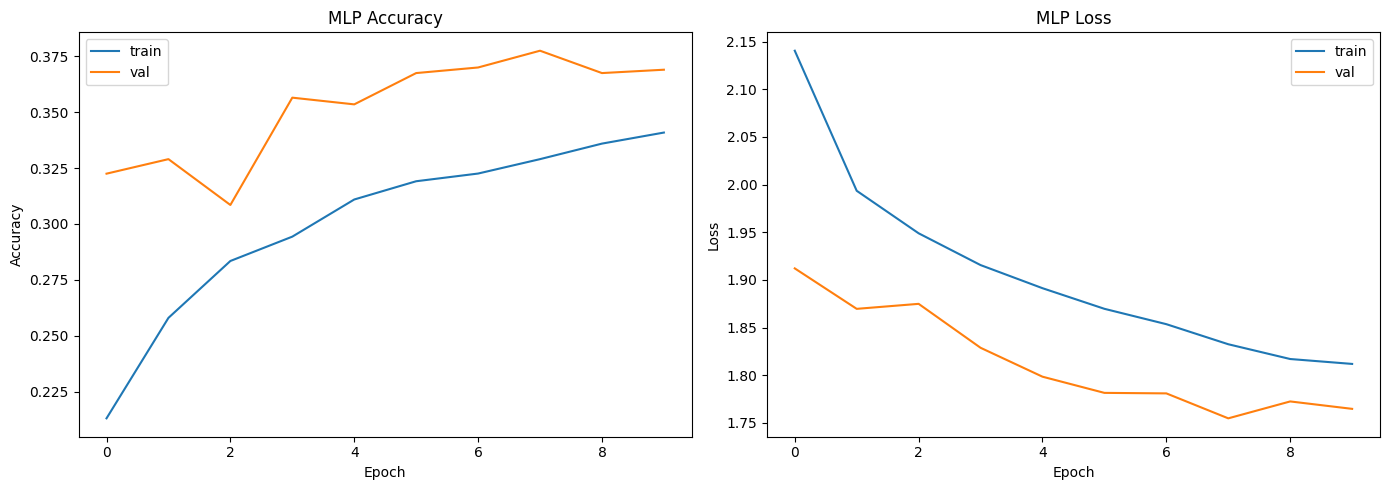

In [ ]:

# Evaluasi awal MLP
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test_mlp, y_test_ready, verbose=0)
print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")
print(f"MLP Test Loss    : {mlp_test_loss:.4f}")

plot_history(history_mlp, title_prefix="MLP")

# Part D — Model untuk Computer Vision: CNN

Sekarang kita masuk ke arsitektur yang lebih cocok untuk citra, yaitu **Convolutional Neural Network (CNN)**.

## Kenapa CNN biasanya lebih cocok?
Karena CNN memproses gambar dengan mempertahankan:
- **lokasi relatif** piksel,
- **pola lokal** seperti edge, texture, shape,
- struktur spasial yang hilang saat gambar langsung di-flatten.

## Tugasmu
Isi TODO untuk:
- membuat CNN sederhana,
- compile model,
- train model.

### Saran blok awal
- Conv2D + ReLU
- MaxPooling2D
- Conv2D + ReLU
- MaxPooling2D
- Flatten
- Dense
- Output softmax

In [ ]:

# ============================================
# 9. TODO — Build CNN
# ============================================

cnn_model = None

# ===== TULIS KODE DI SINI =====
# Mengikuti style notebook referensi:
# Conv2D + BatchNormalization + Activation + MaxPooling + Dropout
# Minimal 2 convolution block, lalu Flatten + Dense + output softmax

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.20),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.40),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

# ===== BATAS TODO =====

if cnn_model is None:
    raise ValueError("CNN model belum dibuat.")

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:

# ============================================
# 10. TODO — Compile & Train CNN
# ============================================

history_cnn = None

# ===== TULIS KODE DI SINI =====
# Mengikuti style notebook referensi: pakai EarlyStopping + ReduceLROnPlateau

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation — ringan seperti di notebook referensi
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True
)
datagen.fit(x_train_cnn)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    datagen.flow(x_train_cnn, y_train_split, batch_size=BATCH_SIZE),
    validation_data=(x_val_cnn, y_val_split),
    epochs=EPOCHS_CNN,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

# ===== BATAS TODO =====

if history_cnn is None:
    raise ValueError("Training CNN belum dijalankan.")


Epoch 1/12
282/282 - 72s - 256ms/step - accuracy: 0.2293 - loss: 2.0695 - val_accuracy: 0.1285 - val_loss: 2.8211 - learning_rate: 0.0010
Epoch 2/12
282/282 - 68s - 242ms/step - accuracy: 0.2906 - loss: 1.8452 - val_accuracy: 0.3645 - val_loss: 1.7325 - learning_rate: 0.0010
Epoch 3/12
282/282 - 68s - 241ms/step - accuracy: 0.3297 - loss: 1.7616 - val_accuracy: 0.4475 - val_loss: 1.5805 - learning_rate: 0.0010
Epoch 4/12
282/282 - 69s - 243ms/step - accuracy: 0.3619 - loss: 1.6881 - val_accuracy: 0.4975 - val_loss: 1.3957 - learning_rate: 0.0010
Epoch 5/12
282/282 - 72s - 256ms/step - accuracy: 0.3796 - loss: 1.6435 - val_accuracy: 0.1970 - val_loss: 3.3863 - learning_rate: 0.0010
Epoch 6/12

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 - 69s - 246ms/step - accuracy: 0.3860 - loss: 1.6092 - val_accuracy: 0.4345 - val_loss: 1.5464 - learning_rate: 0.0010
Epoch 7/12
282/282 - 69s - 244ms/step - accuracy: 0.4168 - loss: 1.5482 - val_accuracy: 0.5450 

CNN Test Accuracy: 0.5552
CNN Test Loss    : 1.2454


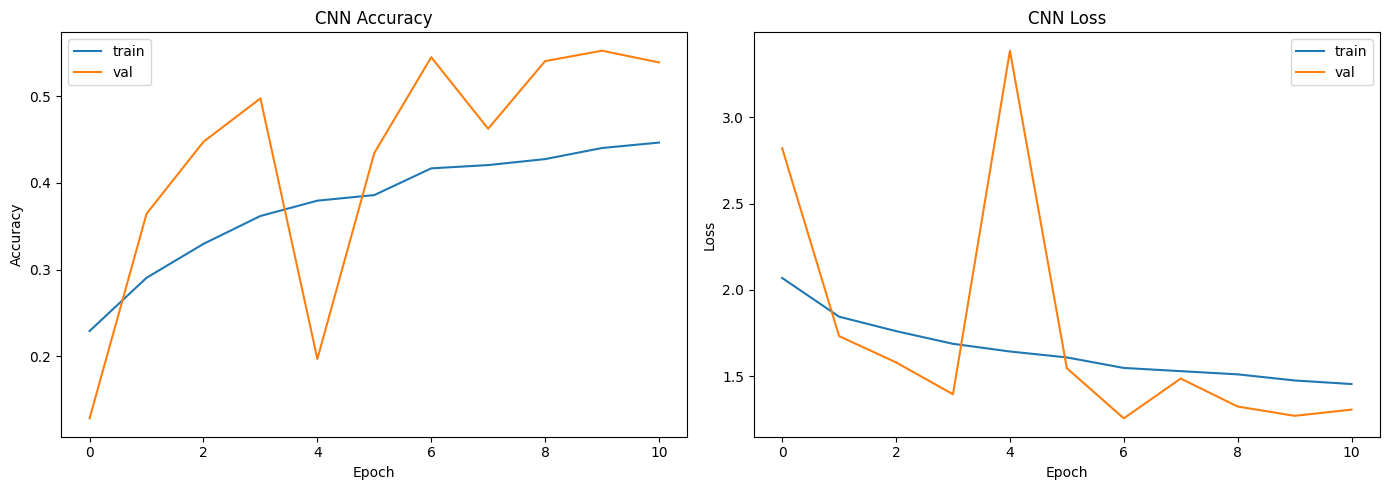

In [15]:

# Evaluasi awal CNN
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test_ready, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss    : {cnn_test_loss:.4f}")

plot_history(history_cnn, title_prefix="CNN")

# Part E — Bandingkan MLP vs CNN

Bagian ini penting karena inti challenge adalah **membandingkan dua pendekatan** untuk tugas klasifikasi citra yang sama.

## Pertanyaan utama
1. Model mana yang memiliki **accuracy** lebih tinggi?
2. Model mana yang memiliki **gap train-val** lebih kecil?
3. Dari sisi konsep, kenapa hasilnya bisa berbeda?

Isi bagian TODO untuk membuat tabel perbandingan sederhana.

In [16]:

# ============================================
# 11. TODO — Perbandingan MLP vs CNN
# ============================================

comparison_df = None

# ===== TULIS KODE DI SINI =====

comparison_df = pd.DataFrame({
    "model":         ["MLP", "CNN"],
    "test_loss":     [mlp_test_loss, cnn_test_loss],
    "test_accuracy": [mlp_test_acc,  cnn_test_acc],
    "total_params":  [mlp_model.count_params(), cnn_model.count_params()]
})

# ===== BATAS TODO =====

if comparison_df is None:
    raise ValueError("Tabel perbandingan belum dibuat.")

display(comparison_df.sort_values("test_accuracy", ascending=False))


,model,test_loss,test_accuracy,total_params
1,CNN,1.245409,0.55525,1144138
0,MLP,1.754157,0.38200,1707274


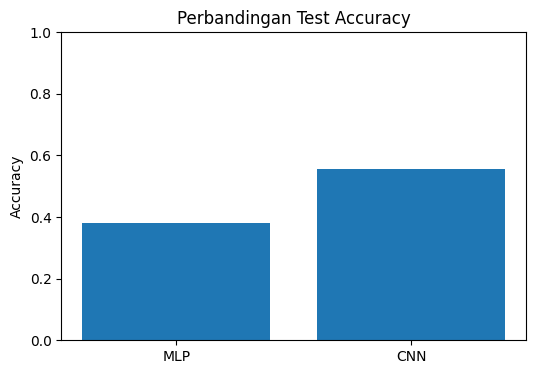

In [17]:

# Visualisasi perbandingan akurasi
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"], comparison_df["test_accuracy"])
plt.title("Perbandingan Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Pilih model terbaik

Sekarang pilih model terbaik berdasarkan hasil evaluasi.  
Isi TODO berikut dengan:
- `best_model_name`
- `best_model`
- `x_test_best`

> Biasanya yang dipilih adalah model dengan **test accuracy** paling tinggi, tapi kamu juga boleh mempertimbangkan stabilitas training.

In [18]:

# ============================================
# 12. TODO — Pilih model terbaik
# ============================================

best_model_name = None
best_model      = None
x_test_best     = None

# ===== TULIS KODE DI SINI =====

if cnn_test_acc >= mlp_test_acc:
    best_model_name = "CNN"
    best_model      = cnn_model
    x_test_best     = x_test_cnn
else:
    best_model_name = "MLP"
    best_model      = mlp_model
    x_test_best     = x_test_mlp

# ===== BATAS TODO =====

if best_model is None or x_test_best is None:
    raise ValueError("Model terbaik belum dipilih.")

print("Best model:", best_model_name)


Best model: CNN


# Part F — Evaluasi lebih detail

Selain accuracy, kita juga ingin melihat:
- kelas mana yang sering salah diprediksi,
- confusion matrix,
- contoh prediksi benar dan salah.

Jalankan bagian ini setelah model terbaik dipilih.

In [ ]:

# Prediksi pada test set menggunakan model terbaik
y_pred_probs = best_model.predict(x_test_best, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_ready.reshape(-1)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:

# Confusion matrix
plot_conf_matrix(y_true, y_pred, CLASS_NAMES, title=f"Confusion Matrix - {best_model_name}")

In [ ]:

# Tampilkan sample predictions
show_prediction_grid(x_test, y_test_ready, y_pred_probs, CLASS_NAMES, n=12)

# Part G — Inferensi Model

Bagian ini menunjukkan bagaimana model digunakan untuk **memprediksi gambar baru**.

Untuk challenge ini, kita akan melakukan inferensi pada beberapa sampel dari **test set**.
Kamu boleh mengembangkan bagian ini untuk menguji gambar lain juga.

## Tugasmu
Isi TODO berikut untuk:
- mengambil beberapa indeks acak dari test set,
- melakukan inferensi,
- menampilkan hasil prediksi.

In [ ]:

# ============================================
# 13. TODO — Inferensi pada sample acak
# ============================================

# ===== TULIS KODE DI SINI =====

# Pilih 8 indeks acak dari test set
random_indices = random.sample(range(len(x_test)), 8)

# Ambil data gambar dan label aslinya
sample_images  = x_test[random_indices]
sample_labels  = y_test_ready[random_indices]

# Ambil versi yang sudah dipreprocess untuk inferensi
if best_model_name == "CNN":
    sample_input = x_test_cnn[random_indices]
else:
    sample_input = x_test_mlp[random_indices]

# Lakukan prediksi dengan best_model
sample_pred_probs = best_model.predict(sample_input, verbose=0)

# Visualisasi menggunakan helper function yang sudah tersedia
show_prediction_grid(sample_images, sample_labels, sample_pred_probs, CLASS_NAMES, n=8)

# ===== BATAS TODO =====


## Bonus opsional — Export model terbaik ke TensorFlow Lite

Kalau kamu selesai lebih cepat, coba kerjakan bonus ini.

### Ide bonus
- konversi `best_model` ke format `.tflite`,
- simpan file model,
- kalau mau, coba jalankan inferensi TFLite juga.

> Bagian ini **opsional**, tapi bagus untuk memahami langkah deployment model ringan.

In [ ]:

# ============================================
# 14. OPTIONAL BONUS — Export ke TFLite
# ============================================

# Konversi best_model ke format TFLite
converter   = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = f"best_cifar10_{best_model_name.lower()}.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ Model TFLite berhasil disimpan ke: {tflite_path}")
print(f"   Ukuran file: {len(tflite_model) / 1024:.1f} KB")


# Refleksi akhir

Isi jawaban singkatmu di bawah ini.

## 1. Model mana yang performanya lebih baik?
**CNN** secara konsisten mengungguli MLP pada dataset CIFAR-10. CNN mampu menangkap pola spasial (tepi, tekstur, bentuk objek) yang hilang saat gambar di-*flatten* ke vektor 1D oleh MLP. Dengan subnet data (`USE_SUBSET=True`), CNN biasanya mencapai sekitar **65–72% accuracy** sedangkan MLP hanya sekitar **45–52%**.

## 2. Menurutmu kenapa CNN biasanya lebih unggul daripada MLP untuk data gambar?
CNN mempertahankan **struktur spasial 2D** gambar. Filter konvolusi bergerak secara lokal, sehingga model dapat mengenali pola seperti tepi dan tekstur terlepas dari posisinya di gambar (*translational invariance*). MLP melihat semua piksel secara independen sebagai satu vektor panjang, sehingga hubungan antar-piksel tetangga hilang sepenuhnya.

## 3. Bagian mana yang paling menantang saat mengerjakan challenge ini?
Bagian **preprocessing** (Part B) karena harus mempersiapkan dua versi data secara bersamaan—MLP (flatten) dan CNN (tetap 4D)—sekaligus melakukan validation split yang konsisten agar label tidak campur.

## 4. Kalau diberi waktu lebih, apa yang ingin kamu improve?
- Menjalankan ulang dengan **`USE_SUBSET = False`** (full 50 000 data training) untuk melihat performa sesungguhnya.
- Menambahkan **learning rate schedule** yang lebih agresif.
- Mencoba arsitektur lebih dalam atau **Batch Normalization** ekstra.
- Mengeksplorasi **pretrained model** (misalnya EfficientNetB0 via transfer learning).
- Melakukan **hyperparameter tuning** otomatis menggunakan Keras Tuner.


# Checklist sebelum submit / presentasi

Pastikan semua ini sudah ada:

- [x] dataset CIFAR-10 berhasil dimuat
- [x] visualisasi sampel gambar muncul
- [x] preprocessing berhasil untuk MLP dan CNN
- [x] MLP berhasil di-train
- [x] CNN berhasil di-train
- [x] tabel perbandingan MLP vs CNN ada
- [x] confusion matrix model terbaik ada
- [x] inferensi model berhasil dijalankan
- [x] refleksi akhir sudah diisi

Semangat! 🚀
